# Epicycles: the Fourier series as a sum of rotating arrows

In Lecture 4 we saw that a function can be treated as a **vector**, and that
a Fourier series expresses that vector as a linear combination of the
orthogonal basis functions $e^{ikt}$. Here we make that combination
*literally visible*.

Write a $2\pi$-periodic curve in the plane as a complex-valued function
$z(t) = x(t) + i\,y(t)$. Its complex Fourier series is

$$
z(t) = \sum_{k=-\infty}^{\infty} c_k\, e^{ikt}, \qquad
c_k = \frac{1}{2\pi}\int_0^{2\pi} z(t)\, e^{-ikt}\, dt .
$$

Each term $c_k e^{ikt}$ is a vector of fixed length $|c_k|$ that spins
around at constant angular speed $k$ (backwards if $k<0$). If we chain the
vectors head-to-tail, in decreasing order of length, the tip of the last one
traces the curve $z(t)$ — this is the classical **epicycle** picture: a
wheel turning on a wheel turning on a wheel.

Truncating the sum after $N$ terms gives the best $N$-term approximation of
$z$ in the norm induced by the inner product $\langle f, g\rangle =
\frac{1}{2\pi}\int_0^{2\pi} f\bar g\, dt$ — exactly the projection idea from
Lecture 4, now applied to a vector-valued (planar) function instead of a
grayscale image.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Circle
import ipywidgets as widgets
from IPython.display import display

%matplotlib widget
plt.rcParams.update({"font.size": 12})


## Generic building blocks

Two ingredients are enough to visualize *any* closed plane curve as
epicycles:

1. **`fourier_coefficients`** turns a parametrization $t \mapsto z(t)$,
   $t \in [0, 2\pi)$, into a set of complex Fourier coefficients $c_k$,
   sorted by decreasing $|c_k|$ so that the first $N$ terms are always the
   best $N$-term approximation.
2. **`epicycle_animation`** draws the chain of rotating circles/arrows for
   the first $N$ terms and animates the parameter $t$, while a slider lets
   you change $N$ live.

In [8]:
def fourier_coefficients(path, n_samples=2000, n_terms=None):
    """Complex Fourier coefficients of a closed curve t -> z(t), t in [0, 2*pi).

    `path` maps an array of t-values to an array of complex z-values (or to
    a (2, len(t)) real array [x; y], which is converted to x + i*y).

    Returns (freqs, coeffs), both sorted by decreasing |coeffs|, such that

        z(t) ~ sum_k coeffs[k] * exp(1j * freqs[k] * t).

    If `n_terms` is given, only the `n_terms` largest coefficients are kept.
    """
    t = np.linspace(0, 2 * np.pi, n_samples, endpoint=False)
    z = np.asarray(path(t))
    if np.iscomplexobj(z) is False and z.ndim == 2:
        z = z[0] + 1j * z[1]

    coeffs = np.fft.fft(z) / n_samples
    freqs = np.fft.fftfreq(n_samples, d=1.0 / n_samples).round().astype(int)

    order = np.argsort(-np.abs(coeffs))
    freqs, coeffs = freqs[order], coeffs[order]

    if n_terms is not None:
        freqs, coeffs = freqs[:n_terms], coeffs[:n_terms]
    return freqs, coeffs


In [9]:
def epicycle_animation(freqs, coeffs, n_frames=240, init_terms=None,
                        figsize=(5.5, 5.5), title=None):
    """Interactive, animated epicycle visualization of

        z(t) = sum_k coeffs[k] * exp(1j * freqs[k] * t),   t in [0, 2*pi).

    `freqs` and `coeffs` should be sorted by decreasing |coeffs| (as
    returned by `fourier_coefficients`), so that a slider selecting the
    first N terms always shows the best N-term approximation.

    Returns the FuncAnimation object -- keep a reference to it (e.g. assign
    the call to a variable) so it is not garbage collected.
    """
    freqs = np.asarray(freqs)
    coeffs = np.asarray(coeffs, dtype=complex)
    n_total = len(freqs)
    if init_terms is None:
        init_terms = n_total

    fig, ax = plt.subplots(figsize=figsize)
    fig.canvas.toolbar_visible = False
    fig.canvas.header_visible = False
    fig.canvas.footer_visible = False

    # Fix the axis limits using the *full* curve, so they don't jump around
    # as N changes.
    t_full = np.linspace(0, 2 * np.pi, 600)
    z_full = sum(c * np.exp(1j * f * t_full) for f, c in zip(freqs, coeffs))
    x_span = max(z_full.real.ptp(), 1e-6)
    y_span = max(z_full.imag.ptp(), 1e-6)
    half = 0.6 * max(x_span, y_span)
    xmid = 0.5 * (z_full.real.min() + z_full.real.max())
    ymid = 0.5 * (z_full.imag.min() + z_full.imag.max())
    ax.set_xlim(xmid - half, xmid + half)
    ax.set_ylim(ymid - half, ymid + half)
    ax.set_aspect("equal")
    ax.set_axis_off()
    if title:
        ax.set_title(title)

    # One (initially invisible) circle per available term.
    circles = [Circle((0, 0), 0, fill=False, lw=1.0, color="C0", alpha=0.5)
               for _ in range(n_total)]
    for circ in circles:
        ax.add_patch(circ)

    arrow_line, = ax.plot([], [], "-o", color="C1", lw=1.3, ms=3, alpha=0.8)
    trace_line, = ax.plot([], [], "-", color="C3", lw=2)
    tip_dot, = ax.plot([], [], "o", color="C3", ms=6)

    trace_x, trace_y = [], []

    n_slider = widgets.IntSlider(
        value=init_terms, min=1, max=n_total, step=1,
        description="# terms", continuous_update=True,
        layout=widgets.Layout(width="320px"),
    )
    speed_slider = widgets.FloatSlider(
        value=1.0, min=0.1, max=4.0, step=0.1, description="speed",
        layout=widgets.Layout(width="260px"),
    )
    reset_button = widgets.Button(description="Restart trace", button_style="")

    state = {"t": 0.0, "prev_t": 0.0}

    def reset_trace(*_):
        trace_x.clear()
        trace_y.clear()

    reset_button.on_click(reset_trace)
    n_slider.observe(reset_trace, names="value")

    dt = 2 * np.pi / n_frames

    def update(_frame):
        N = n_slider.value
        state["t"] += dt * speed_slider.value
        t = state["t"] % (2 * np.pi)
        if t < state["prev_t"]:
            trace_x.clear()
            trace_y.clear()
        state["prev_t"] = t

        partial_sums = np.cumsum(coeffs[:N] * np.exp(1j * freqs[:N] * t))
        centers = np.concatenate(([0j], partial_sums[:-1]))
        radii = np.abs(coeffs[:N])

        for i, circ in enumerate(circles):
            if i < N:
                circ.center = (centers[i].real, centers[i].imag)
                circ.radius = radii[i]
                circ.set_visible(radii[i] > 1e-9)
            else:
                circ.set_visible(False)

        chain = np.concatenate(([0j], partial_sums))
        arrow_line.set_data(chain.real, chain.imag)

        tip = partial_sums[-1]
        trace_x.append(tip.real)
        trace_y.append(tip.imag)
        trace_line.set_data(trace_x, trace_y)
        tip_dot.set_data([tip.real], [tip.imag])

        return circles + [arrow_line, trace_line, tip_dot]

    anim = FuncAnimation(fig, update, interval=30, blit=False,
                          cache_frame_data=False)

    display(widgets.VBox([widgets.HBox([n_slider, speed_slider, reset_button]),
                           fig.canvas]))
    return anim


## Simplest example: epicycles of planetary motion

Ptolemy modeled retrograde planetary motion, as seen from Earth, with a
**deferent** (a big circle) carrying an **epicycle** (a small circle) on its
rim. In our language that is nothing but a two-term Fourier series

$$
z(t) = c_1\, e^{i t} + c_2\, e^{i k t},
$$

with $|c_1| \gg |c_2|$ and $k$ an integer several times larger than $1$. Move
the "# terms" slider between $1$ and $2$: with one term you get a plain
circular orbit; adding the second term produces the little retrograde loops
that puzzled astronomers for centuries -- long before anyone called this a
Fourier series.

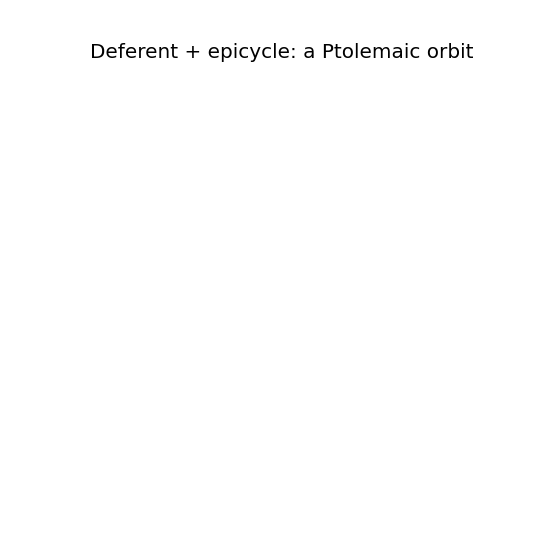

In [10]:
freqs_planet = np.array([1, 8])
coeffs_planet = np.array([1.0, 0.28 * np.exp(1j * 0.6)])

anim_planet = epicycle_animation(
    freqs_planet, coeffs_planet, init_terms=2,
    title="Deferent + epicycle: a Ptolemaic orbit",
)


## Cool example: a complicated plane curve

Lecture 1 introduced the outline of a cat, already given as an explicit
(real) Fourier series `cat_path(t)` with harmonics up to order 30
([source](https://www.geogebra.org/m/pH8wD3rW)). We reuse it here, convert
it to a complex curve $z(t) = x(t) + i\,y(t)$, and let
`fourier_coefficients` recover its complex Fourier coefficients numerically
via the FFT. Sliding "# terms" from $1$ up to about $60$ shows a wobbly
blob sharpening, term by term, into the exact cat silhouette.

In [5]:
exp = np.exp
sin = np.sin
cos = np.cos

# This is a path that for 0 <= t <= 2*pi traces out the outline of a cat.
# Source: https://www.geogebra.org/m/pH8wD3rW
cat_path = lambda t:  np.array([-(721 *sin(t))/4+196/3 *sin(2 *t)-86/3 *sin(3 *t)-131/2 *sin(4 *t)+477/14 *sin(5 *t)+27 *sin(6 *t)-\
     29/2 *sin(7 *t)+68/5 *sin(8 *t)+1/10 *sin(9 *t)+23/4 *sin(10 *t)-19/2 *sin(12 *t)-85/21 *sin(13 *t)+\
     2/3 *sin(14 *t)+27/5 *sin(15 *t)+7/4 *sin(16 *t)+17/9 *sin(17 *t)-4 *sin(18 *t)-1/2 *sin(19 *t)+\
     1/6 *sin(20 *t)+6/7 *sin(21 *t)-1/8 *sin(22 *t)+1/3 *sin(23 *t)+3/2 *sin(24 *t)+13/5 *sin(25 *t)+\
     sin(26 *t)-2 *sin(27 *t)+3/5 *sin(28 *t)-1/5 *sin(29 *t)+1/5 *sin(30 *t)+(2337 *cos(t))/8-\
     43/5 *cos(2 *t)+322/5 *cos(3 *t)-117/5 *cos(4 *t)-26/5 *cos(5 *t)-23/3 *cos(6 *t)+143/4 *cos(7 *t)-\
     11/4 *cos(8 *t)-31/3 *cos(9 *t)-13/4 *cos(10 *t)-9/2 *cos(11 *t)+41/20 *cos(12 *t)+8 *cos(13 *t)+\
     2/3 *cos(14 *t)+6 *cos(15 *t)+17/4 *cos(16 *t)-3/2 *cos(17 *t)-29/10 *cos(18 *t)+11/6 *cos(19 *t)+\
     12/5 *cos(20 *t)+3/2 *cos(21 *t)+11/12 *cos(22 *t)-4/5 *cos(23 *t)+cos(24 *t)+17/8 *cos(25 *t)-\
     7/2 *cos(26 *t)-5/6 *cos(27 *t)-11/10 *cos(28 *t)+1/2 *cos(29 *t)-1/5 *cos(30 *t), -(637 *sin(t))/2-\
     188/5 *sin(2 *t)-11/7 *sin(3 *t)-12/5 *sin(4 *t)+11/3 *sin(5 *t)-37/4 *sin(6 *t)+8/3 *sin(7 *t)+\
     65/6 *sin(8 *t)-32/5 *sin(9 *t)-41/4 *sin(10 *t)-38/3 *sin(11 *t)-47/8 *sin(12 *t)+5/4 *sin(13 *t)-\
     41/7 *sin(14 *t)-7/3 *sin(15 *t)-13/7 *sin(16 *t)+17/4 *sin(17 *t)-9/4 *sin(18 *t)+8/9 *sin(19 *t)+\
     3/5 *sin(20 *t)-2/5 *sin(21 *t)+4/3 *sin(22 *t)+1/3 *sin(23 *t)+3/5 *sin(24 *t)-3/5 *sin(25 *t)+\
     6/5 *sin(26 *t)-1/5 *sin(27 *t)+10/9 *sin(28 *t)+1/3 *sin(29 *t)-3/4 *sin(30 *t)-(125 *cos(t))/2-\
     521/9 *cos(2 *t)-359/3 *cos(3 *t)+47/3 *cos(4 *t)-33/2 *cos(5 *t)-5/4 *cos(6 *t)+31/8 *cos(7 *t)+\
     9/10 *cos(8 *t)-119/4 *cos(9 *t)-17/2 *cos(10 *t)+22/3 *cos(11 *t)+15/4 *cos(12 *t)-5/2 *cos(13 *t)+\
     19/6 *cos(14 *t)+7/4 *cos(15 *t)+31/4 *cos(16 *t)-cos(17 *t)+11/10 *cos(18 *t)-2/3 *cos(19 *t)+\
     13/3 *cos(20 *t)-5/4 *cos(21 *t)+2/3 *cos(22 *t)+1/4 *cos(23 *t)+5/6 *cos(24 *t)+3/4 *cos(26 *t)-\
     1/2 *cos(27 *t)-1/10 *cos(28 *t)-1/3 *cos(29 *t)-1/19 *cos(30 *t)])

cat_z = lambda t: cat_path(t)[0] + 1j * cat_path(t)[1]


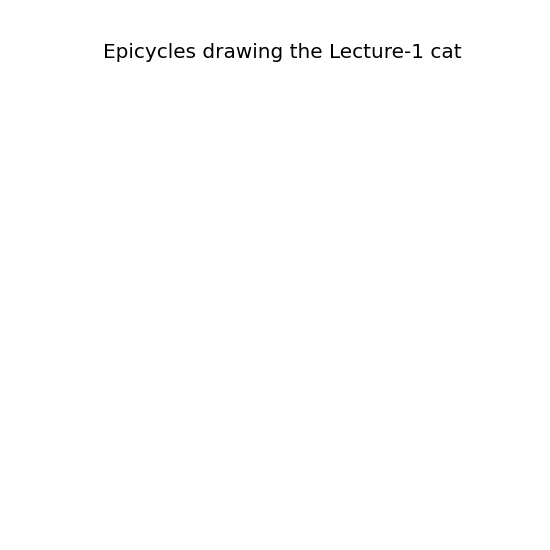

In [11]:
freqs_cat, coeffs_cat = fourier_coefficients(cat_z, n_samples=2000, n_terms=61)

anim_cat = epicycle_animation(
    freqs_cat, coeffs_cat, init_terms=8,
    title="Epicycles drawing the Lecture-1 cat",
)


## What to notice

- Every one of these pictures is the *same* mathematical object: a
  truncated Fourier series $\sum_{k} c_k e^{ikt}$, just with different
  coefficients.
- Sorting the terms by $|c_k|$ means the slider always shows the best
  possible $N$-term approximation -- exactly the projection theorem from
  Lecture 4, now for a planar curve instead of an image.
- The two-term planetary toy model shows that a "complicated" phenomenon
  (retrograde loops) can come from *adding just one more basis vector*.
- With about 60 terms the cat outline is reproduced almost exactly, since
  `cat_path` itself only contains harmonics up to order 30 -- the FFT simply
  rediscovers coefficients that were there by construction.

$$
\boxed{\text{Fourier series} = \text{sum of orthogonal basis vectors} = \text{epicycles}}
$$